# Verificación de supuestos


Los supuestos son indispensables en el modelo de regresión pues garantizan la veracidad de las estimaciones, intervalos de confianza y pruebas de hipótesis hechas.

Supuestos del modelo de regresión:

- Homocedasticidad (No heterocedasticidad)
- Linealidad (No multicolinealidad)
- Normalidad de los errores.
- Independencia de los errores/observaciones.

Será de interés verificar que se cumplan (o casi) estos supuestos realizando un análisis de los residuales. A continuación mostraremos algunas herramientas computacionales de utilidad al momento de realizar la validación de supuestos.



# Ejemplo

Seguiremos trabajando con un conjunto de datos conocido.

In [7]:
datos <-  data.frame(mtcars)

# prepro
datos$am <- factor(datos$am, levels = c(0,1))
datos$vs <- factor(datos$vs, levels = c(0,1))
datos$cyl <- factor(datos$cyl, levels = c(4,6,8))
datos$gear <- factor(datos$gear, levels= c(3,4,5))
datos$carb <- factor(datos$carb, levels= c(1,2,3,4,6,8))


modelo1<- lm(mpg ~ wt + hp + cyl, data = datos)

summary(modelo1)


Call:
lm(formula = mpg ~ wt + hp + cyl, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2612 -1.0320 -0.3210  0.9281  5.3947 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 35.84600    2.04102  17.563 2.67e-16 ***
wt          -3.18140    0.71960  -4.421 0.000144 ***
hp          -0.02312    0.01195  -1.934 0.063613 .  
cyl6        -3.35902    1.40167  -2.396 0.023747 *  
cyl8        -3.18588    2.17048  -1.468 0.153705    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.44 on 27 degrees of freedom
Multiple R-squared:  0.8572,	Adjusted R-squared:  0.8361 
F-statistic: 40.53 on 4 and 27 DF,  p-value: 4.869e-11


Procederemos con la verificación de supuestos con ayuda de gráficas y algunas pruebas de hipótesis. Esta evaluación puede ser subjetiva, por lo que es importante definir que no existe una regla. Lo ideal es identificar las características que no son deseables en un gráfico y tomarlo como referencia.

### Diagnóstico general


Al aplicar la función `plot()` a un modelo de regresión, nos muestra algunas gráficas generales de utilidad.

1. **Residuals vs Fitted Plot**

Esta gráfica evalúa el supuesto de linealidad y la ausencia de patrones en los residuos.  

Caso ideal:

- Los residuos deben mostrarse "aleatoriamente" alrededor de la línea horizontal en 0.
- No debe observarse estructura, curvatura ni tendencia.

Indicios de incumplimiento:

- Curvaturas marcadas, que indican falta de linealidad.
- Forma de embudo, asociada con heterocedasticidad.
- Patrones visibles que sugieren variables omitidas.

2. **Normal Q-Q Plot**

Esta gráfica evalúa el supuesto de normalidad en los residuos. 

Caso ideal:

- Los puntos deben alinearse aproximadamente sobre la recta identidad.
- Pequeñas desviaciones en las colas son "aceptables".

Indicios de incumplimiento:

- Colas alejadas de la recta identidad, que indican colas pesadas.
- Asimetría notoria.
- Curvatura en forma de “S”, típica de distribuciones no normales.

3. **Scale-Location Plot**

Esta gráfica evalúa el supuesto de homocedasticidad, es decir, que la varianza de los residuos sea constante.  

Caso ideal:

- Los puntos deben formar una banda relativamente "uniforme".
- La curva suavizada debe permanecer casi horizontal.

Indicios de incumplimiento:

- Estructuras de embudo, asociadas con varianza creciente o decreciente.
- Tendencias ascendentes o descendentes en la curva roja.

4. **Residuals vs Leverage Plot**

Esta gráfica permite identificar observaciones influyentes resaltando las observaciones que tienen una distancia de Cook "grande".

La distancia de Cook es una medida que indica cuánto cambiarían los coeficientes de un modelo de regresión si elimináramos una observación específica, por lo que ayuda a identificar valores "influyentes".


Caso ideal:

- La mayoría de los puntos deben ubicarse lejos de las curvas de Cook.

Indicios de incumplimiento:

- Puntos cercanos o por fuera de las curvas de Cook.
- Combinaciones de residuos grandes con leverage alto.



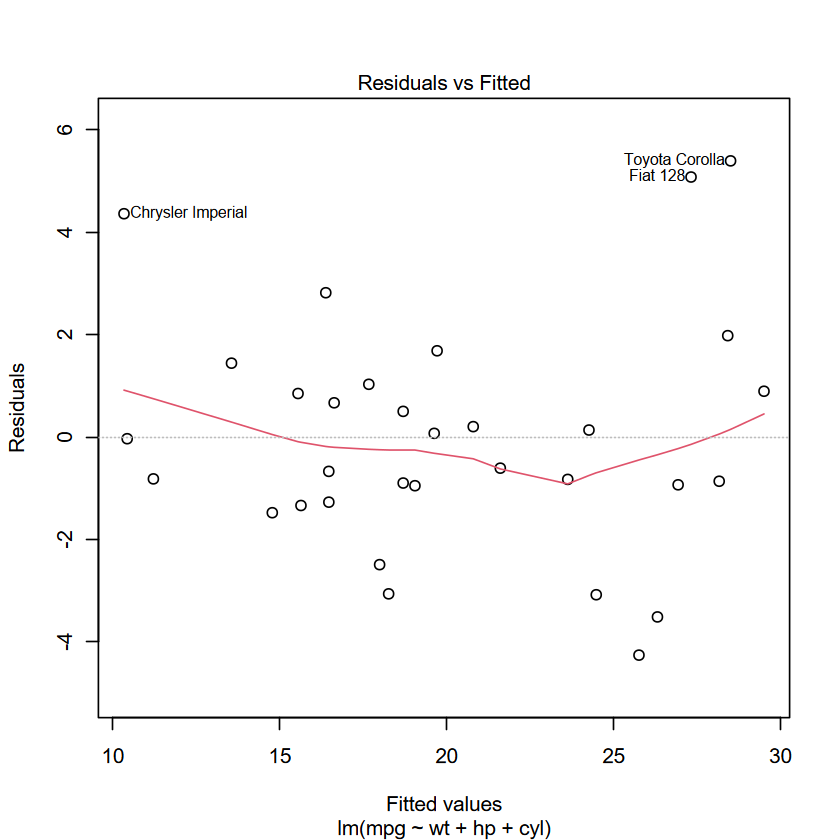

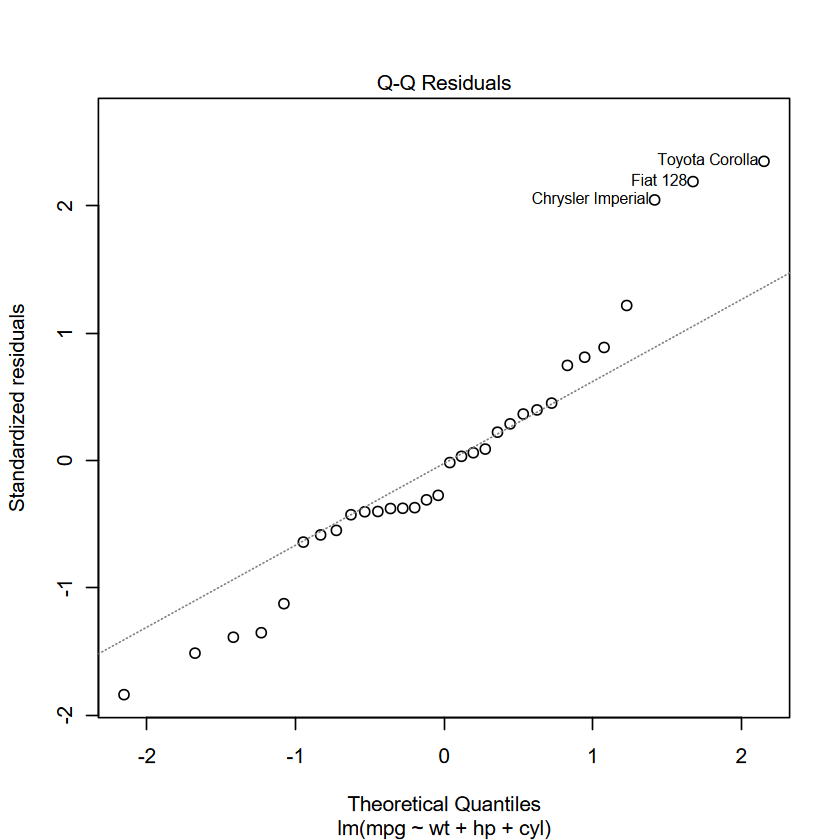

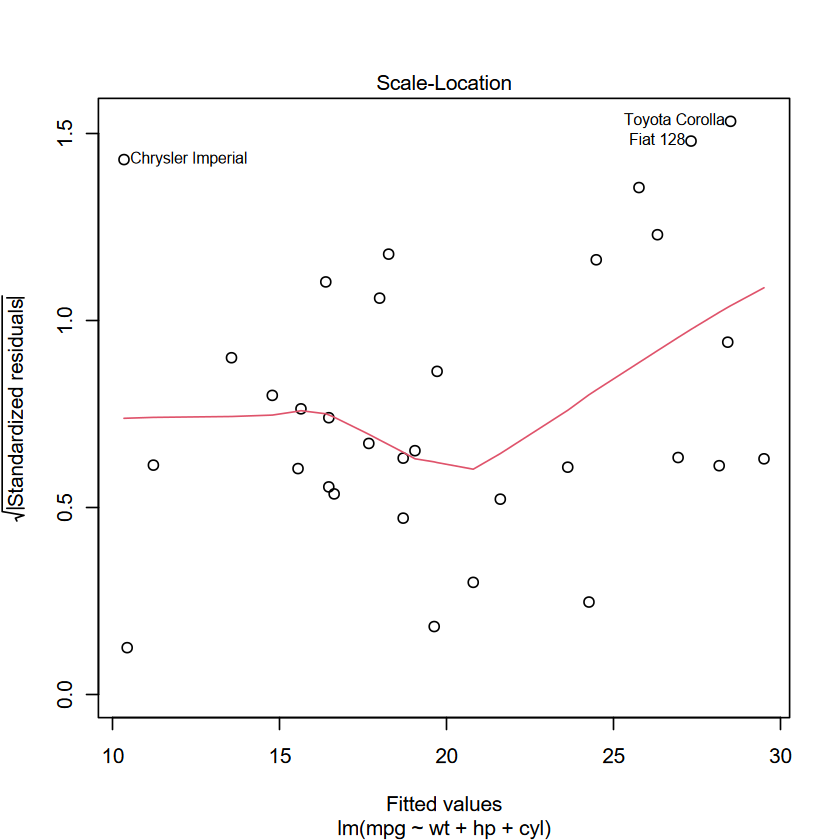

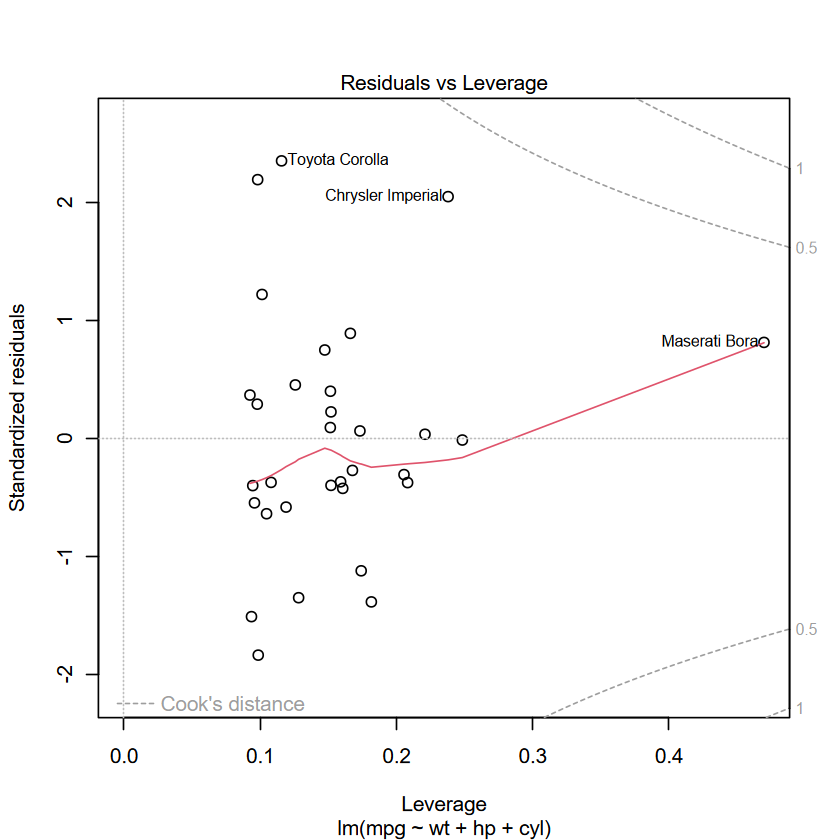

In [8]:
plot(modelo1)


## Homocedasticidad


Las pruebas de hipótesis usadas para verificar este supuesto tienen la forma:

$$
H_{0}: \text{Varianza constante} \quad H_{1}: \text{Heterocedasticidad}
$$

In [9]:
library(lmtest)

bptest(modelo1)

Cargando paquete requerido: zoo


Adjuntando el paquete: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  modelo1
BP = 6.1707, df = 4, p-value = 0.1868


In [10]:
library(car)

ncvTest(modelo1)

Cargando paquete requerido: carData



Non-constant Variance Score Test 
Variance formula: ~ fitted.values 
Chisquare = 3.374465, Df = 1, p = 0.066214

## Linealidad

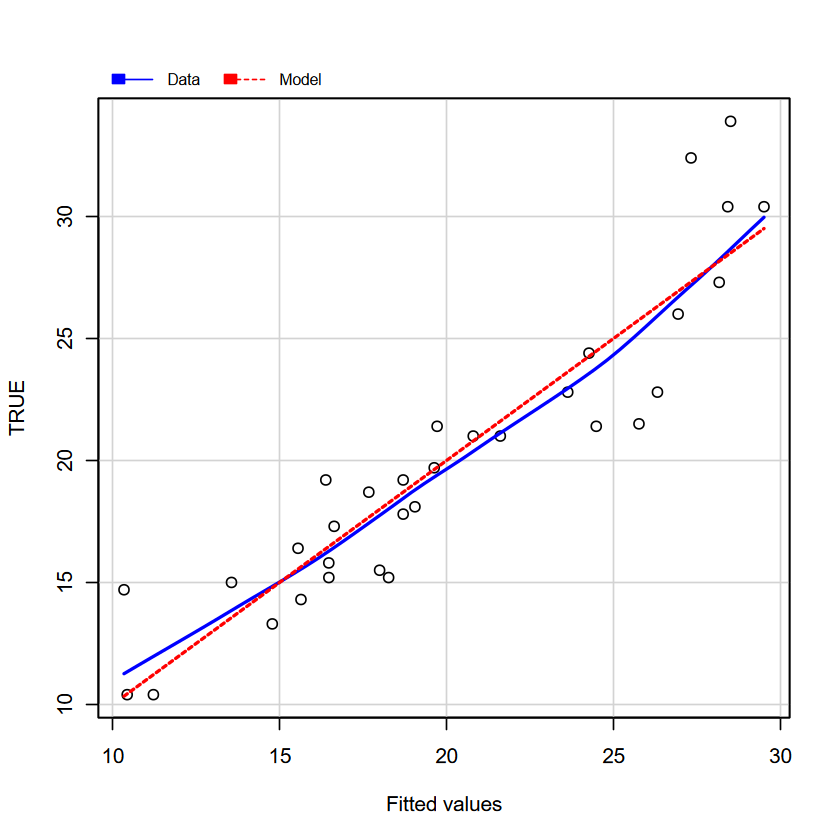

In [12]:
marginalModelPlot(modelo1)

           Test stat Pr(>|Test stat|)   
wt            2.1693         0.039388 * 
hp            1.6485         0.111274   
cyl                                     
Tukey test    2.7228         0.006473 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


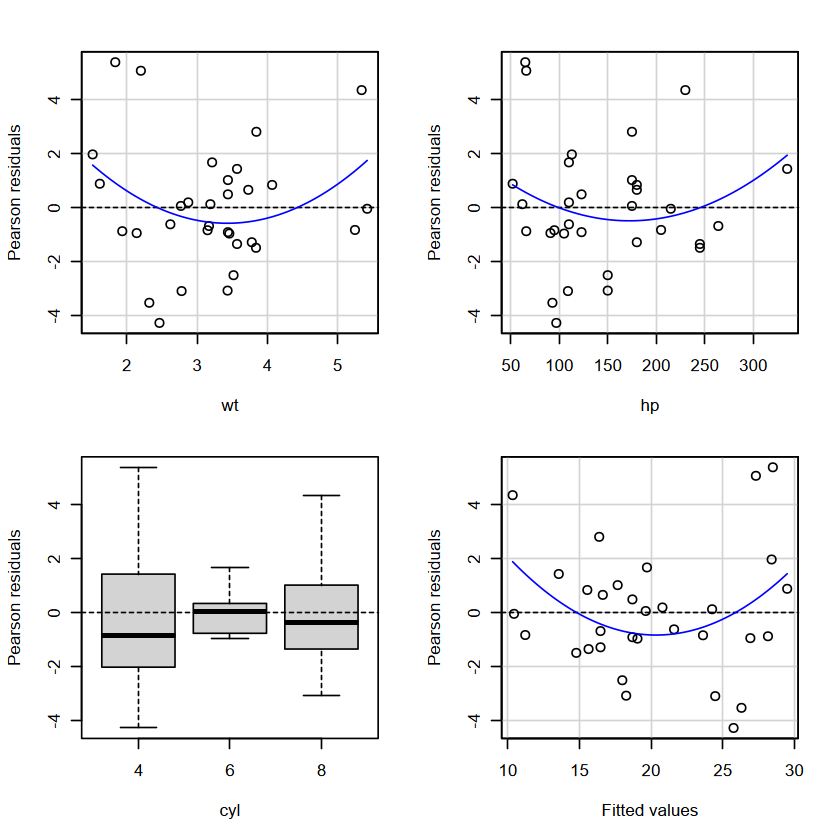

In [11]:
residualPlots(modelo1)

## Normalidad de los errores

## Independencia/ Covarianza cero de los errores

# Arreglando la verificación de supuestos

## Transformaciones Box-Cox

## Transformaciones Box-Tidwell